In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
from cycler import cycler
from scipy.ndimage import uniform_filter1d

warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)


# functions

In [2]:
def newmean(dfexpt):
    
    tot =pd.DataFrame()
    tott = pd.DataFrame()
    speeds = dfexpt.filter(regex="meanSpeed.*").rolling(30,min_periods=1).mean() 
    tot['totalmeanspeed'] = speeds.mean(axis=1)
    tot['SEM'] = speeds.sem(axis=1)*1.96 
    tott = pd.concat([tot, dfexpt], axis = 1)
    tott = tott.iloc[:1723,:]

    return tott

In [3]:
def filterfour(dfs):
    p4 = dfs.filter(regex="bodypart4.*")
    p5 = dfs.filter(regex="bodypart1.*")
    p6 = dfs.filter(regex="bodypart9.*")
    p7 = dfs.filter(regex="bodypart7.*")

    df = pd.concat([dfs['frame'],p5,p6], axis =1)
    df = df.iloc[:1751,:]
    
    return df

# Lineplots

In [4]:
tpath1 = "D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Worm tracking\\ML\\Processed\\Reprocced\\"
genotype = "KCR1GS"
wt_genotype = "WT-Blue"

if genotype == "KCR1-ET":
    colorp = "#2d5016"
    palette = "inferno"
if genotype == "ACR":
    colorp = "#e66a2f"
    palette = "viridis"
if genotype == "KCR2":
    colorp = "#3182ce"
    palette = "Greens_r"
if genotype == "KCR1GS":
    colorp = "#59318d"
if "WT" in genotype:
    colorp = "#575757"
    palette = "Greys_r"
    
df = pd.read_csv(tpath1 + genotype+ ".csv")
df = df.drop(columns=df.columns[0], axis=1)

In [5]:
inter_font_path = "D:" + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Regular.ttf"
inter_bold_path = "D:" + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Bold.ttf"
inter_italic_path = "D:" + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Italic.ttf"

# Register fonts
import matplotlib.font_manager as fm
fm.fontManager.addfont(inter_font_path)
fm.fontManager.addfont(inter_bold_path)
fm.fontManager.addfont(inter_italic_path)

# Set Inter as default font
plt.rcParams['font.family'] = 'Inter'

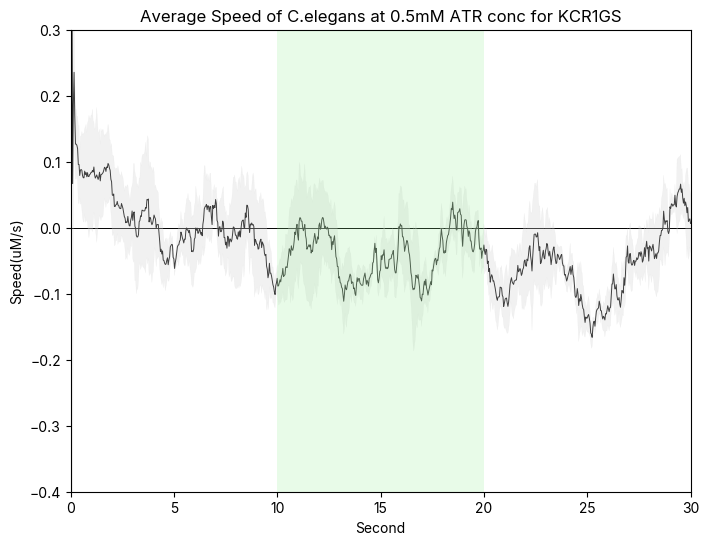

In [6]:
import matplotlib as mpl
conc = [ "1x_"]

dfexpt1 = df.filter(regex = genotype + ".*") 
dfexpt = dfexpt1.filter(regex="^((?!0x_).)*$")
dfwt = df.filter(regex = wt_genotype + ".*")

for i in conc:
    if i == "0x_":
        label = "0mM"
    if i == "0.5x_":
        label = "0.25mM"
    if i == "1x_":
        label = "0.5mM"
    if i == "2x_":
        label = "1mM"
    if i == "4x_":
        label = "2mM"
    

    crazywt = newmean(pd.concat([df.iloc[:,0:2], dfwt.filter(regex = i + ".*")], axis=1)).iloc[:877,:]

    fig, ax = plt.subplots(figsize=(8, 6))
        
    plt.plot(crazywt['second'], crazywt['totalmeanspeed'], color = "black", linewidth = 0.7,  zorder=1, label='_nolegend_')
    plt.fill_between(crazywt['second'], crazywt['totalmeanspeed'] -crazywt['SEM'] ,crazywt['totalmeanspeed'] + crazywt['SEM'],color = "lightgray", alpha =0.3, linewidth = 0.2, label='_nolegend_')
    plt.axhline(y = 0, color="black", linewidth = "0.7", zorder = 0)
    
    rectangle = plt.Rectangle((10,-1), 10, 1.5, fc='lightgreen', alpha = 0.2, zorder=1)
    plt.gca().add_patch(rectangle)
    ax.set_ylim([-0.4,0.3])
    ax.set_xlim(0,30)
    ax.set_xlabel('Second')    
    ax.set_ylabel('Speed(uM/s)')
    ax.set_title('Average Speed of C.elegans at ' + label +' ATR conc for ' + genotype )
    mpl.rcParams['svg.fonttype'] = 'none' 
    #fig.savefig(os.path.join(tpath1, 'Line plots\\',  "WT" + ' at ' + label + ' concentration_speedplot (allthroughnormalization).svg'), dpi = 300)

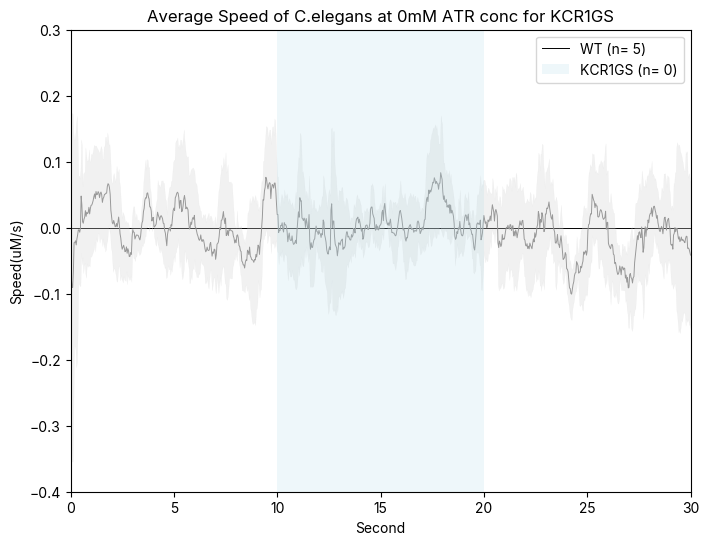

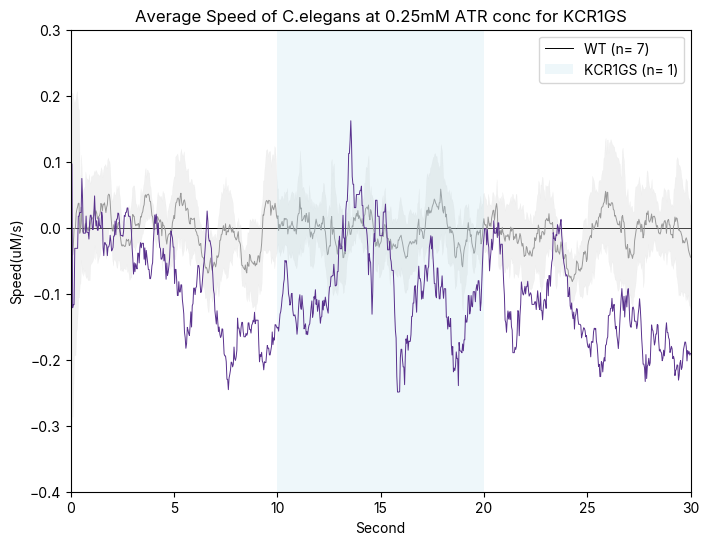

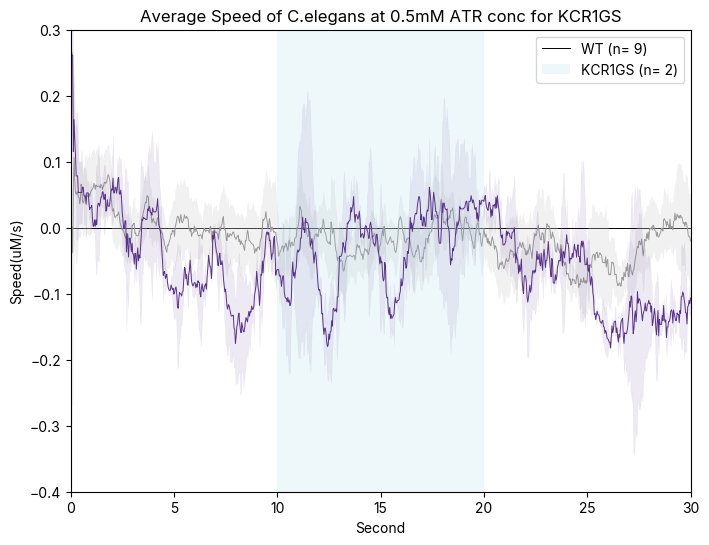

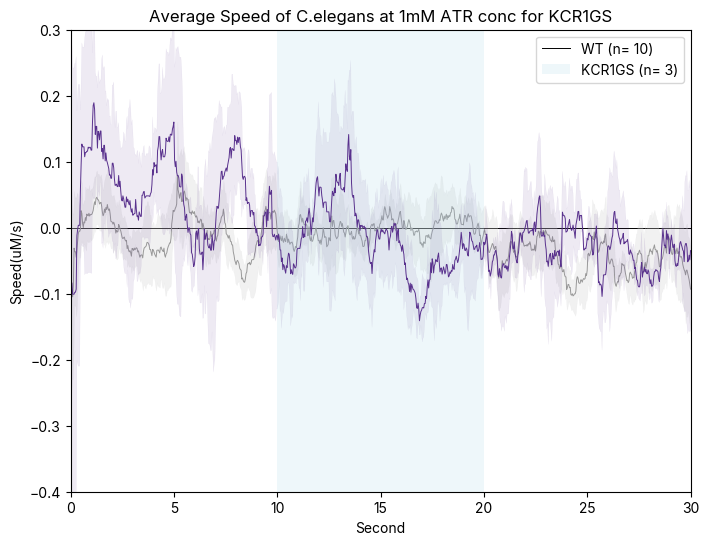

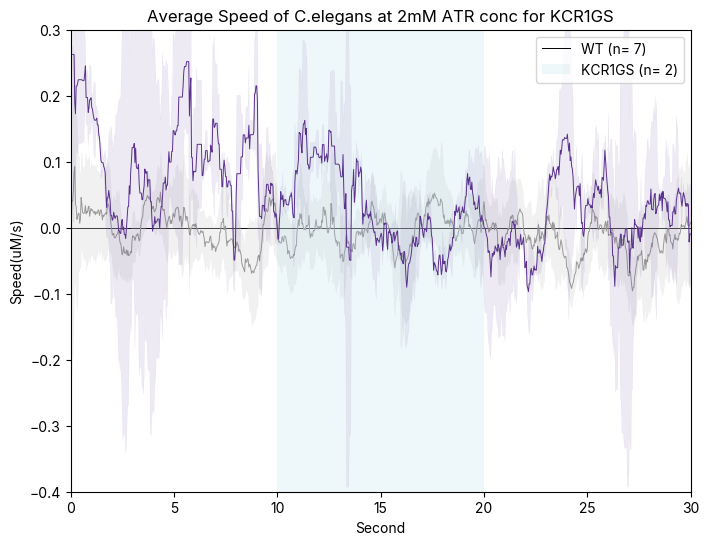

In [8]:
import matplotlib as mpl
conc = ["0x_", "0.5x_", "1x_", "2x_", "4x_"]

dfexpt1 = df.filter(regex = genotype + ".*") 
dfexpt = dfexpt1.filter(regex="^((?!0x_).)*$")
dfwt = df.filter(regex = wt_genotype + ".*")

for i in conc:
    if i == "0x_":
        label = "0mM"
    if i == "0.5x_":
        label = "0.25mM"
    if i == "1x_":
        label = "0.5mM"
    if i == "2x_":
        label = "1mM"
    if i == "4x_":
        label = "2mM"
    
    crazyexpt = newmean(pd.concat([df.iloc[:,0:2], dfexpt.filter(regex = i + ".*")], axis=1)).iloc[:877,:]   #only first 30s
    crazywt = newmean(pd.concat([df.iloc[:,0:2], dfexpt1.filter(regex = "0x.*"), dfwt.filter(regex = i + ".*")], axis=1)).iloc[:877,:]

    fig, ax = plt.subplots(figsize=(8, 6))
        
    plt.plot(crazywt['second'], crazywt['totalmeanspeed'], color = "grey", linewidth = 0.7,  zorder=1, label='_nolegend_')
    plt.fill_between(crazywt['second'], crazywt['totalmeanspeed'] -crazywt['SEM'] ,crazywt['totalmeanspeed'] + crazywt['SEM'],color = "lightgray", alpha =0.3, linewidth = 0.2, label='_nolegend_')

    plt.plot(crazyexpt['second'], crazyexpt['totalmeanspeed'], color = colorp, linewidth = 0.7,zorder=2, label='_nolegend_')
    plt.fill_between(crazyexpt['second'], crazyexpt['totalmeanspeed'] -crazyexpt['SEM'] ,crazyexpt['totalmeanspeed'] + crazyexpt['SEM'],color =colorp, alpha = 0.1, linewidth = 0.2, label='_nolegend_')
    plt.axhline(y = 0, color="black", linewidth = "0.7", zorder = 0)
    
    rectangle = plt.Rectangle((10,-1), 10, 1.5, fc='lightblue', alpha = 0.2, zorder=1)
    plt.gca().add_patch(rectangle)
    ax.set_ylim([-0.4,0.3])
    ax.set_xlim(0,30)
    ax.set_xlabel('Second')    
    ax.set_ylabel('Speed(uM/s)')
    ax.set_title('Average Speed of C.elegans at ' + label +' ATR conc for ' + genotype )
    ax.legend(['WT (n= ' + str(int(len(crazywt.columns)-4)) + ")", genotype + ' (n= ' + str(int(len(crazyexpt.columns)-4)) + ")"], loc="upper right")
    mpl.rcParams['svg.fonttype'] = 'none' 
    fig.savefig(os.path.join(tpath1, 'Line plots\\',  genotype + ' at ' + label + ' concentration_speedplot (allthroughnormalization).svg'), dpi = 300)